In [1]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(CURRENT_DIR)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'try_ts')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [2]:
df = pd.read_parquet(os.path.join(DATA_PATH, 'DWLR', 'dwlr.parquet'))
df

,Date,Water_Level_m,Temperature_C,Rainfall_mm,pH,Dissolved_Oxygen_mg_L
0,2023-01-01,2.124836,-0.601831,26.958453,6.948386,8.282231
1,2023-01-02,2.099955,0.396578,15.306932,6.952946,7.998230
2,2023-01-03,2.146121,0.139768,29.263846,6.912783,8.173989
3,2023-01-04,2.196756,0.327833,8.246142,6.972447,8.079537
4,2023-01-05,2.115765,-0.917756,35.654194,6.962424,8.425726
...,...,...,...,...,...,...
360,2023-12-27,4.598495,3.328421,32.910361,7.394505,9.593726
361,2023-12-28,4.656033,3.480948,32.347558,7.395879,9.761713
362,2023-12-29,4.580826,3.823570,39.089482,7.397253,9.250805
363,2023-12-30,4.613217,2.341459,31.426052,7.398626,9.943686


In [3]:
df.set_index('Date', inplace=True)
df

,Water_Level_m,Temperature_C,Rainfall_mm,pH,Dissolved_Oxygen_mg_L
Date,,,,,
2023-01-01,2.124836,-0.601831,26.958453,6.948386,8.282231
2023-01-02,2.099955,0.396578,15.306932,6.952946,7.998230
2023-01-03,2.146121,0.139768,29.263846,6.912783,8.173989
2023-01-04,2.196756,0.327833,8.246142,6.972447,8.079537
2023-01-05,2.115765,-0.917756,35.654194,6.962424,8.425726
...,...,...,...,...,...
2023-12-27,4.598495,3.328421,32.910361,7.394505,9.593726
2023-12-28,4.656033,3.480948,32.347558,7.395879,9.761713
2023-12-29,4.580826,3.823570,39.089482,7.397253,9.250805


In [4]:
df.index = pd.to_datetime(df.index)

In [5]:
nan_counts = df.isna().sum()
print((nan_counts/len(df))*100)

Water_Level_m            0.000000
Temperature_C            0.000000
Rainfall_mm              0.000000
pH                       0.000000
Dissolved_Oxygen_mg_L    5.479452
dtype: float64


In [6]:
# Interpolar los datos faltantes
df.interpolate(method='time', inplace=True)

# Verificar si quedan valores faltantes
print(df.isna().sum())

Water_Level_m            0
Temperature_C            0
Rainfall_mm              0
pH                       0
Dissolved_Oxygen_mg_L    0
dtype: int64


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Water_Level_m,365.0,3.432689,0.773076,2.093622,2.722986,3.737387,4.114597,4.656033
Temperature_C,365.0,13.772649,8.105750,-2.158371,6.491563,14.636813,21.016989,27.993951
Rainfall_mm,365.0,105.195185,81.624762,7.497851,39.821698,78.451984,136.680474,315.102779
pH,365.0,7.259963,0.604575,6.900317,7.053846,7.154121,7.283242,11.418093
Dissolved_Oxygen_mg_L,365.0,8.776515,0.537049,7.632790,8.397023,8.742446,9.193446,9.987240


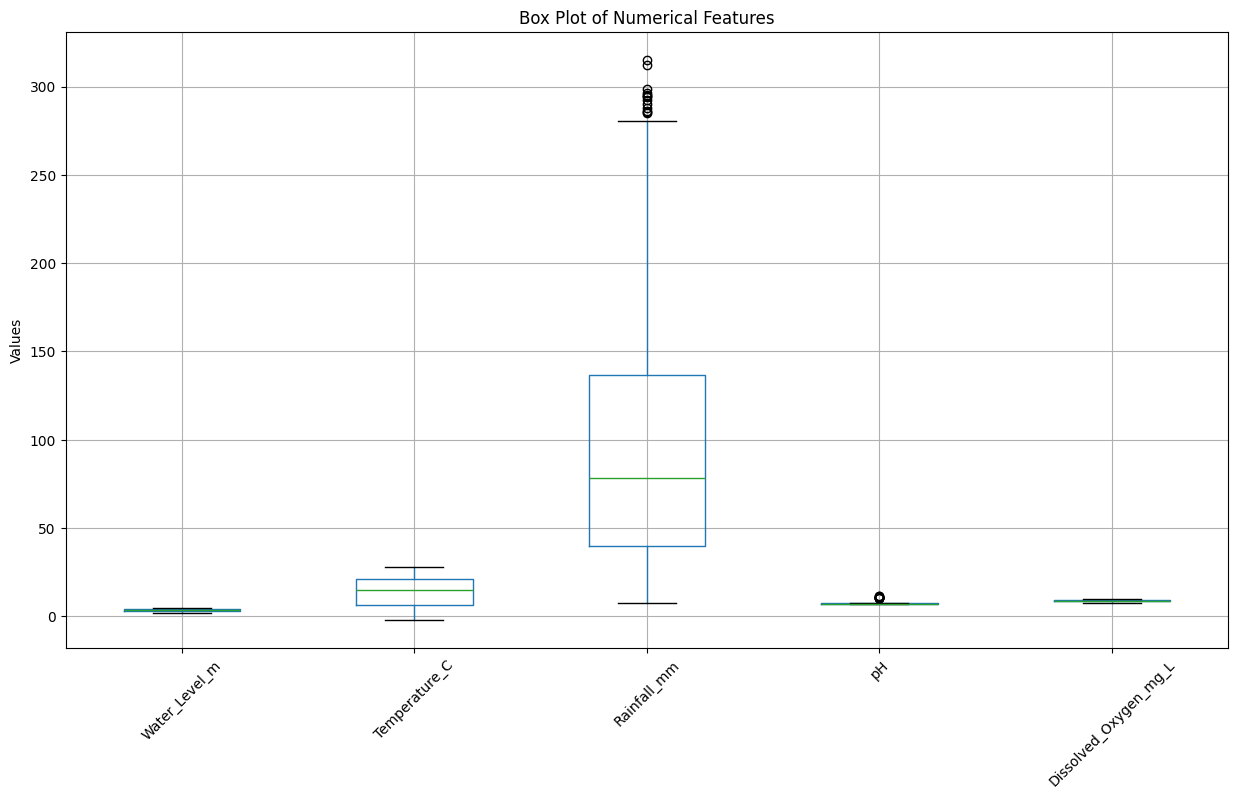

In [8]:
# Create a box plot for all numerical columns in the DataFrame
df.boxplot(figsize=(15, 8), rot=45)
plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [9]:
# Calcular el número de outliers para cada columna numérica
outliers_percentage = {}
for column in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_percentage[column] = f'{round(((df[column] < lower_bound) | (df[column] > upper_bound)).sum()/len(df) * 100, 4)} %'

# Mostrar el número de outliers por columna
outliers_percentage

{'Water_Level_m': '0.0 %',
 'Temperature_C': '0.0 %',
 'Rainfall_mm': '3.5616 %',
 'pH': '2.7397 %',
 'Dissolved_Oxygen_mg_L': '0.0 %'}

In [10]:
df['y'] = df['Dissolved_Oxygen_mg_L']
df.drop(columns=['Dissolved_Oxygen_mg_L'], inplace=True)

In [11]:
df.to_parquet(os.path.join(DATA_PATH, 'DWLR', 'clean.parquet'))